In [78]:
# Library import
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [79]:
# Data load 
email_df = pd.read_csv('../data/raw/email_campaigns_log.csv')
add_df = pd.read_csv('../data/raw/linkedin_ads_perf.csv')

In [80]:
# eda for email_df
email_df = email_df.copy()
email_df.sample(10)

,campaign_id,date,emails_sent,emails_opened,emails_clicked,bounces
9,CAMP_PRO_AI_2026,2026-05-23,15174,3065,108,427.0
8,CAMP_RECRUIT_GROWTH,2026-05-22,15723,3667,135,NaN
52,CAMP_B2B_TALENT,2026-06-06,16290,3735,98,207.0
70,CAMP_B2B_TALENT,2026-06-12,15036,2950,138,265.0
79,CAMP_B2B_TALENT,2026-06-15,9606,2344,7,4322.0
66,CAMP_PRO_AI_2026,2026-06-11,13279,2449,121,218.0
47,CAMP_RECRUIT_GROWTH,2026-06-04,13203,3218,143,382.0
82,CAMP_B2B_TALENT,2026-06-16,17492,3338,84,476.0
18,CAMP_PRO_AI_2026,2026-05-26,12526,2891,135,347.0
41,CAMP_RECRUIT_GROWTH,2026-06-02,12103,2867,138,359.0


In [90]:
email_df.duplicated().sum()

np.int64(0)

* **No duplicates**

In [81]:
email_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   campaign_id     96 non-null     str    
 1   date            96 non-null     str    
 2   emails_sent     96 non-null     int64  
 3   emails_opened   96 non-null     int64  
 4   emails_clicked  96 non-null     int64  
 5   bounces         93 non-null     float64
dtypes: float64(1), int64(3), str(2)
memory usage: 7.1 KB


In [82]:
email_df['date'] = pd.to_datetime(email_df['date']).dt.date
email_df['bounces'] = email_df['bounces'].fillna(0).astype('int')


* **Data format:** Data data type must be transformed into `datetime`, `bounces`changed to integer 
* **Null values:** bounces contains null values. 
* `bounces` filled with 0, means no bounces that particular day. 


In [99]:
email_df.describe()

,emails_sent,emails_opened,emails_clicked,bounces
count,96.000000,96.000000,96.000000,96.000000
mean,14862.239583,3136.052083,108.979167,473.947917
std,2125.768863,521.822522,36.351784,1048.913868
min,9606.000000,2055.000000,7.000000,0.000000
25%,13559.250000,2762.500000,86.000000,228.250000
50%,15104.000000,3130.500000,107.000000,291.000000
75%,16031.250000,3544.500000,138.000000,361.500000
max,21157.000000,4324.000000,177.000000,7490.000000


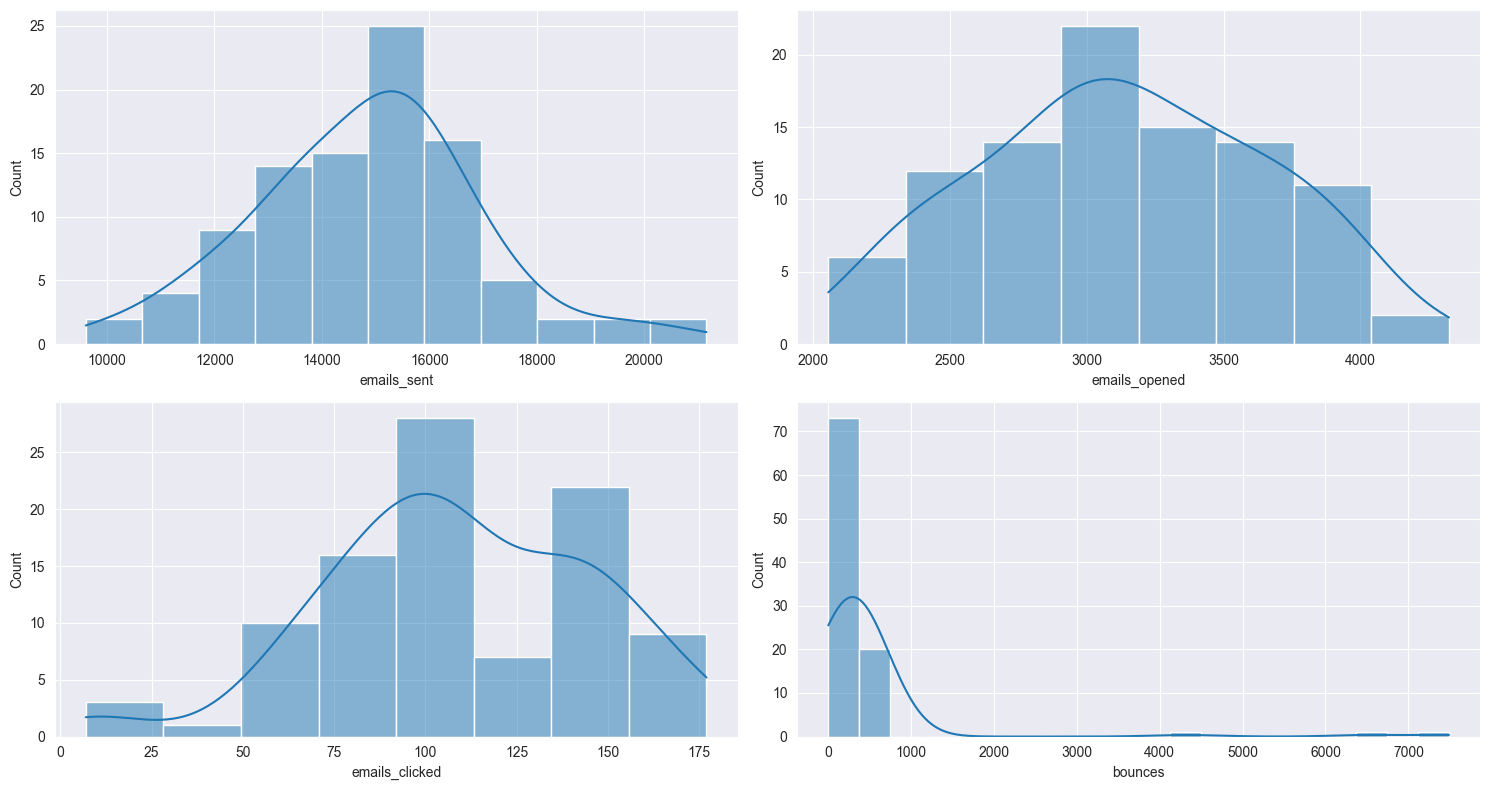

In [83]:
fig, ax = plt.subplots(2,2, figsize=(15,8))
set_style='darkgrid'
ax = ax.flatten()
sns.histplot(data = email_df, x = 'emails_sent', kde = True, ax=ax[0])
sns.histplot(data = email_df, x = 'emails_opened',kde = True, ax=ax[1])
sns.histplot(data = email_df, x = 'emails_clicked', kde = True, ax=ax[2])
sns.histplot(data = email_df, x = 'bounces', kde = True, ax=ax[3])

plt.tight_layout()
plt.show()

In [84]:
# ads eda 

add_df =add_df.copy()
add_df.sample(10)

,campaign_id,date,impressions,clicks,spend_usd,conversions
19,CAMP_B2B_TALENT,2026-05-26,46428,596,1544.34,66
82,CAMP_B2B_TALENT,2026-06-16,39633,579,1403.49,65
86,CAMP_RECRUIT_GROWTH,2026-06-17,55245,545,1403.10,65
27,CAMP_PRO_AI_2026,2026-05-29,44611,383,854.48,48
80,CAMP_RECRUIT_GROWTH,2026-06-15,44467,541,1211.97,74
34,CAMP_B2B_TALENT,2026-05-31,46886,382,1027.08,43
79,CAMP_B2B_TALENT,2026-06-15,49728,617,1362.25,82
91,CAMP_B2B_TALENT,2026-06-19,46371,497,1179.49,58
73,CAMP_B2B_TALENT,2026-06-13,45106,588,1547.63,77
26,CAMP_RECRUIT_GROWTH,2026-05-28,50409,611,1355.38,62


In [91]:
add_df.duplicated().sum()

np.int64(0)

* **No duplicates**

In [85]:
add_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   campaign_id  96 non-null     str    
 1   date         96 non-null     str    
 2   impressions  96 non-null     int64  
 3   clicks       96 non-null     int64  
 4   spend_usd    95 non-null     float64
 5   conversions  96 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 7.1 KB


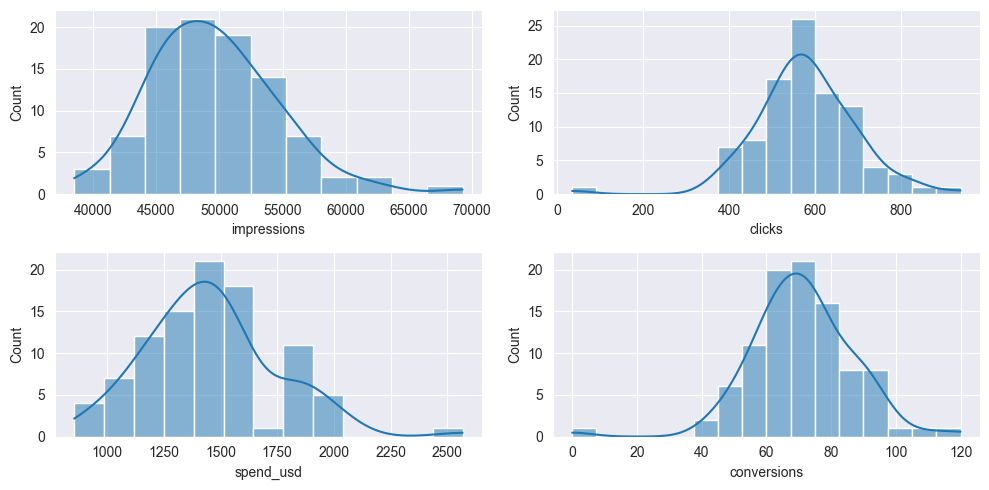

In [86]:
# Histplot for clicks and spend_usd 

fig, ax = plt.subplots(2,2,figsize =(10,5), sharex=False)
ax = ax.flatten()
sns.histplot(data = add_df, x = 'impressions',kde = True, ax=ax[0])
sns.histplot(data = add_df, x = 'clicks',kde = True, ax=ax[1])
sns.histplot(data = add_df, x = 'spend_usd',kde = True, ax=ax[2])
sns.histplot(data = add_df, x = 'conversions',kde = True, ax=ax[3])

plt.tight_layout()
plt.show()

* **Null values:** spend_usd cotains null values, must be addressed with careful. 

In [87]:
# Data imputation for spend_usd, using campaing historical data for mean calculation 

    # cpc historcial per campaing 
add_df['cpc-temp'] = add_df['spend_usd'] / add_df['clicks']
cpc_average_campaign = add_df.groupby('campaign_id')['cpc-temp'].transform('mean')
estimate_spend = add_df['clicks'] * cpc_average_campaign
add_df['spend_usd'] = add_df['spend_usd'].fillna(estimate_spend).round(2)
add_df.drop(columns ='cpc-temp', inplace = True)
add_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   campaign_id  96 non-null     str    
 1   date         96 non-null     str    
 2   impressions  96 non-null     int64  
 3   clicks       96 non-null     int64  
 4   spend_usd    96 non-null     float64
 5   conversions  96 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 7.1 KB


In [92]:
print(email_df.duplicated(subset=['date', 'campaign_id']).sum())
print(add_df.duplicated(subset=['date', 'campaign_id']).sum())

0
0


In [89]:
# Joint with both dataset to create a global dataset
df_jointed = pd.merge(
    email_df, 
    add_df, 
    on =['date','campaign_id'],
    how ='outer'
)
df_jointed.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   campaign_id     192 non-null    str    
 1   date            192 non-null    object 
 2   emails_sent     96 non-null     float64
 3   emails_opened   96 non-null     float64
 4   emails_clicked  96 non-null     float64
 5   bounces         96 non-null     float64
 6   impressions     96 non-null     float64
 7   clicks          96 non-null     float64
 8   spend_usd       96 non-null     float64
 9   conversions     96 non-null     float64
dtypes: float64(8), object(1), str(1)
memory usage: 18.3+ KB


In [94]:
metrics = ['emails_sent', 'emails_opened', 'emails_clicked', 'bounces',
'impressions', 'clicks', 'spend_usd', 'conversions']

df_jointed[metrics] = df_jointed[metrics].fillna(0)


* **Null values** handled by filling with 0. 

In [ ]:
# Integrity control 

# Rule 1: email clicks can´t be greater than email opened. 
try:
    assert (df_jointed['emails_clicked'] <= df_jointed['emails_opened']).all(), "⚠️ email_clicked > emails_opened"

# Rule 2: Clicks on adds can't be greater than impressions
    assert (df_jointed['clicks'] <= df_jointed['impressions']).all(), "⚠️ adds cliked > impressions"

# Rule 3: No null data in the final dataset
    assert df_jointed.isnull().sum().sum() == 0, "⚠️ Null data in the final dataset"

    print("Assert results: status, ok to proceed")
except AssertionError as e:
    print(f"Validation error:{e}")
